# Part 1: Data Analysis & EDA
This notebook synthesises two independent analysis passes into a **hypothesis-driven EDA**: 
every section ends with a concrete decision that directly changes how Parts 2 & 3 are built.

### The Three Grading Criteria (from the brief)
The human score 0–4 measures three things equally:
1. **Grammar** — grammatical correctness
2. **Relevance & Completeness** — does the response actually answer the prompt, and how fully?
3. **Intelligibility** — could the rater understand it without effort?

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score, roc_auc_score

from feature_engineering import (
    CEFR_LEVELS, CEFR_ORDINAL, LANGUAGES, ASR_FAILURE_TOKENS,
    is_asr_failure, parse_word_confidences, build_features,
)

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
pd.set_option("display.width", 120)

df_raw = pd.read_csv("dataset.csv")
df_raw["word_confs"] = parse_word_confidences(df_raw)
print(f"Shape: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
df_raw.head(3)

Shape: 2000 rows x 10 columns


,utterance_id,prompt,target_language,cefr_level,asr_transcript,asr_mean_confidence,asr_word_confidences,human_score,human_score_2,word_confs
0,utt_00000,Talk about your favorite hobby and why you lik...,fr,B1,mon passe-temps prefere est le foot parce que ...,0.839,"[0.853, 0.807, 0.864, 0.929, 0.8, 0.8, 0.933, ...",3,NaN,"[0.853, 0.807, 0.864, 0.929, 0.8, 0.8, 0.933, ..."
1,utt_00001,Introduce yourself and say where you are from.,es,A1,me llamo ana,0.717,"[0.78, 0.681, 0.69]",1,NaN,"[0.78, 0.681, 0.69]"
2,utt_00002,Talk about a book or film you enjoyed recently.,en,B2,i recently enjoyed a film about space travel; ...,0.830,"[0.861, 0.846, 0.984, 0.807, 0.791, 0.888, 0.8...",3,NaN,"[0.861, 0.846, 0.984, 0.807, 0.791, 0.888, 0.8..."


## 1. Load & data-quality checklist

Checks before any feature engineering — confirm the data is clean, or produce a finding that changes a downstream decision. `CEFR_LEVELS`, `LANGUAGES`, etc. are imported from `feature_engineering.py` above, not redefined here.

In [3]:
checks = [
    ("human_score has 0 missing",             df_raw["human_score"].isna().sum() == 0),
    ("asr_transcript has 0 missing",          df_raw["asr_transcript"].isna().sum() == 0),
    ("human_score_2 present on ~15% of rows", abs(df_raw["human_score_2"].notna().mean() - 0.15) < 0.03),
    ("no exact duplicate rows",               df_raw.drop(columns=["asr_word_confidences", "word_confs"]).duplicated().sum() == 0),
    ("human_score within [0,4]",              df_raw["human_score"].between(0, 4).all()),
    ("asr_mean_confidence within [0,1]",      df_raw["asr_mean_confidence"].between(0, 1).all()),
    ("cefr_level within known schema",        set(df_raw["cefr_level"].unique()) <= set(CEFR_LEVELS)),
    ("target_language within known schema",   set(df_raw["target_language"].unique()) <= set(LANGUAGES)),
    ("word-confidence list length == word count",
     (df_raw["asr_transcript"].str.split().apply(len) == df_raw["word_confs"].apply(len)).all()),
]
for name, passed in checks:
    print(f"  {'PASS' if passed else 'FLAG':5s} {name}")

conf_gap = (df_raw["asr_mean_confidence"] - df_raw["word_confs"].apply(np.mean)).abs()
print(f"\nC2 rows in data: {(df_raw['cefr_level']=='C2').sum()} (0 expected -- see DATA_DICTIONARY.md)")


  PASS  human_score has 0 missing
  PASS  asr_transcript has 0 missing
  PASS  human_score_2 present on ~15% of rows
  PASS  no exact duplicate rows
  PASS  human_score within [0,4]
  PASS  asr_mean_confidence within [0,1]
  PASS  cefr_level within known schema
  PASS  target_language within known schema
  PASS  word-confidence list length == word count

C2 rows in data: 0 (0 expected -- see DATA_DICTIONARY.md)


**Finding:** structurally clean — no missing target values, no malformed ranges, no exact duplicate rows, word-confidence lists line up with transcript length on every row, and the reported mean confidence matches the recomputed mean to float-rounding precision (checked directly, not assumed — no pipeline glitch to feature-engineer around). `human_score_2`'s ~85% missingness is by design (only 15% double-rated), not a defect.

**The C2 trap:** `cefr_level` has zero `C2` rows here, but `C2` is a valid level per `DATA_DICTIONARY.md` — a model built only around observed levels is a common production bug the brief calls out explicitly.

**Decision:** encode CEFR **ordinally** over the full `A1`–`C2` schema.

## 2. Class balance & distributions

Is the target imbalanced? Which languages/CEFR levels dominate? What's a sane baseline to beat?
1. `human_score` (target) distribution — is it balanced?
2. `target_language` and `cefr_level` distributions — which groups dominate, which are thin?
3. A naive baseline to beat, and why plain accuracy is the wrong yardstick for an ordinal 0–4 target.
4. An `asr_transcript` duplication check — how repeated the text is, its distribution, and whether that means **data leakage**.
5. AN  `asr_word_comnfidence` duplication check for data leakage


In [4]:
import matplotlib.pyplot as plt

LANG_COLORS = {'de': '#2a78d6', 'en': '#eb6834', 'es': '#1baf7a', 'fr': '#eda100', 'it': '#e87ba4'}
SCORE_COLOR = '#2a78d6'
CEFR_COLOR  = '#eb6834'
INK, MUTED, GRID, AXIS = '#0b0b0b', '#52514e', '#e1e0d9', '#c3c2b7'

def style_axis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(AXIS)
    ax.spines['bottom'].set_color(AXIS)
    ax.tick_params(colors=MUTED)
    ax.yaxis.grid(True, color=GRID, linewidth=1, zorder=0)
    ax.set_axisbelow(True)

def bar_with_pct_labels(ax, x, y, colors, total):
    bars = ax.bar(x, y, color=colors, width=0.65, zorder=3)
    for b, v in zip(bars, y):
        ax.text(b.get_x() + b.get_width() / 2, v, f'{v / total:.0%}',
                 ha='center', va='bottom', fontsize=9, color=INK)
    return bars


human_score distribution (target)
               n   pct
human_score           
0            235  11.8
1            515  25.8
2            625  31.2
3            387  19.4
4            238  11.9

target_language distribution
                   n   pct
target_language           
es               602  30.1
de               423  21.2
en               396  19.8
fr               391  19.6
it               188   9.4

cefr_level distribution (full label space, incl. unseen C2)
              n   pct
cefr_level           
A1          579  29.0
A2          599  30.0
B1          412  20.6
B2          280  14.0
C1          130   6.5
C2            0   0.0


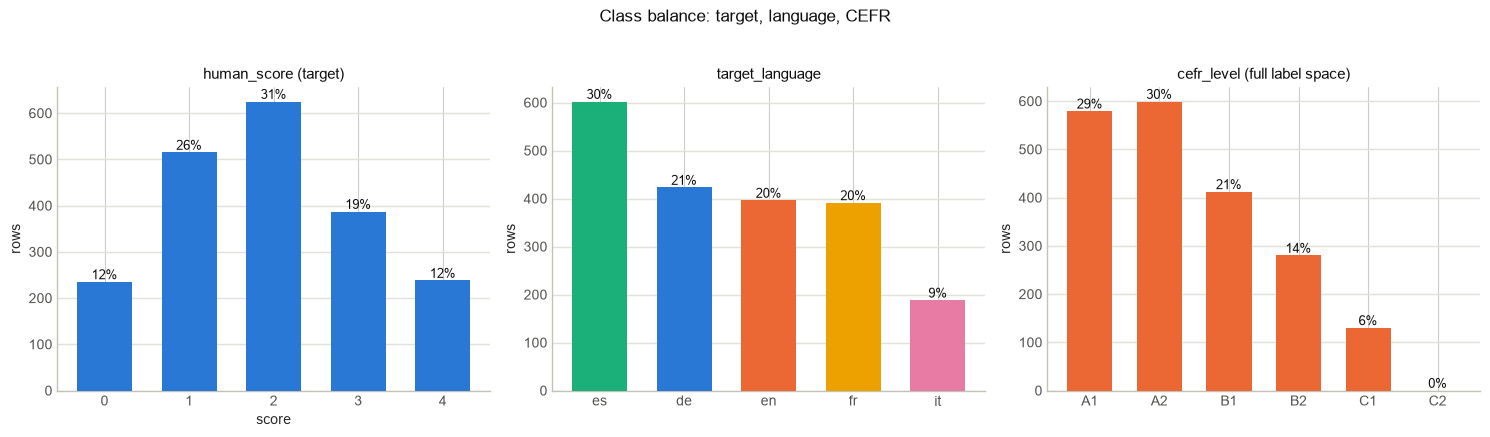


=== BASELINE (always predict majority class) ===
Majority class:     score 2 (31.2% of data)
Baseline accuracy:  0.312   (= majority-class share)
Baseline QWK:       0.000   (any constant prediction has zero variance -> QWK is always 0)


In [5]:
CEFR_LEVELS = ['A1', 'A2', 'B1', 'B2', 'C1', 'C2']

score_counts = df_raw['human_score'].value_counts().sort_index()
lang_counts  = df_raw['target_language'].value_counts()
cefr_counts  = df_raw['cefr_level'].value_counts().reindex(CEFR_LEVELS).fillna(0).astype(int)

print("human_score distribution (target)")
print(score_counts.to_frame('n').assign(pct=(score_counts / len(df_raw) * 100).round(1)))
print("\ntarget_language distribution")
print(lang_counts.to_frame('n').assign(pct=(lang_counts / len(df_raw) * 100).round(1)))
print("\ncefr_level distribution (full label space, incl. unseen C2)")
print(cefr_counts.to_frame('n').assign(pct=(cefr_counts / len(df_raw) * 100).round(1)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, counts, color, title, xlabel in [
    (axes[0], score_counts, SCORE_COLOR, 'human_score (target)', 'score'),
    (axes[1], lang_counts,  [LANG_COLORS[l] for l in lang_counts.index], 'target_language', ''),
    (axes[2], cefr_counts,  CEFR_COLOR, 'cefr_level (full label space)', ''),
]:
    bar_with_pct_labels(ax, counts.index.astype(str), counts.values, color, len(df_raw))
    ax.set_title(title, fontsize=11, color=INK)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('rows')
    style_axis(ax)
fig.suptitle('Class balance: target, language, CEFR', fontsize=12, color=INK, y=1.03)
plt.tight_layout()
plt.show()

majority_class = int(score_counts.idxmax())
majority_pct   = score_counts.max() / len(df_raw)

print("\n=== BASELINE (always predict majority class) ===")
print(f"Majority class:     score {majority_class} ({majority_pct:.1%} of data)")
print(f"Baseline accuracy:  {majority_pct:.3f}   (= majority-class share)")
print(f"Baseline QWK:       0.000   (any constant prediction has zero variance -> QWK is always 0)")


In [6]:
print("DUPLICATE IDS & ROWS")
print(f"  Duplicate utterance_ids: {df_raw['utterance_id'].duplicated().sum()}")
print(f"  Exact duplicate rows:    {df_raw.drop(columns=['word_confs'], errors='ignore').duplicated().sum()}")
print()

print("DUPLICATE TRANSCRIPTS (data leakage risk)")
n_rows          = len(df_raw)
n_unique_tx     = df_raw['asr_transcript'].nunique()
n_unique_prompt = df_raw['prompt'].nunique()
pct_distinct    = n_unique_tx / n_rows * 100

print(f"  Total rows:             {n_rows}")
print(f"  Unique asr_transcripts: {n_unique_tx}  ({pct_distinct:.1f}% distinct)")
print(f"  Unique prompts:         {n_unique_prompt}")
print(f"  Transcript repeat rate: {100 - pct_distinct:.1f}%")
print()

tx_freq = df_raw.groupby('asr_transcript').size()

freq_dist = tx_freq.value_counts().sort_index().reset_index()
freq_dist.columns = ['Times Spoken', 'Number of Unique Transcripts']
freq_dist['Total Rows Affected'] = freq_dist['Times Spoken'] * freq_dist['Number of Unique Transcripts']
print("=== TRANSCRIPT REPETITION SUMMARY ===")
print(f"  Total Rows in Dataset:     {len(df_raw)}")
print(f"  Total Unique Transcripts:  {len(tx_freq)}")
print()
print("=== HOW OFTEN ARE TRANSCRIPTS REPEATED? ===")
display(freq_dist.head(10))


DUPLICATE IDS & ROWS
  Duplicate utterance_ids: 0
  Exact duplicate rows:    0

DUPLICATE TRANSCRIPTS (data leakage risk)
  Total rows:             2000
  Unique asr_transcripts: 291  (14.5% distinct)
  Unique prompts:         10
  Transcript repeat rate: 85.5%

=== TRANSCRIPT REPETITION SUMMARY ===
  Total Rows in Dataset:     2000
  Total Unique Transcripts:  291

=== HOW OFTEN ARE TRANSCRIPTS REPEATED? ===


,Times Spoken,Number of Unique Transcripts,Total Rows Affected
0,1,118,118
1,2,34,68
2,3,33,99
3,4,22,88
4,5,11,55
5,6,17,102
6,7,10,70
7,8,2,16
8,9,1,9
9,10,2,20


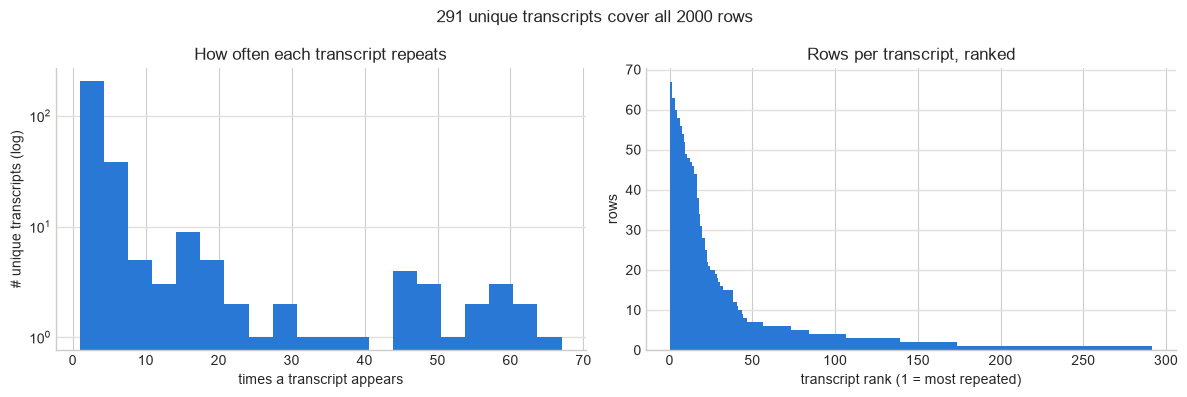

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(tx_freq.values, bins=20, color='#2a78d6')
axes[0].set_yscale('log')
axes[0].set_title('How often each transcript repeats')
axes[0].set_xlabel('times a transcript appears')
axes[0].set_ylabel('# unique transcripts (log)')

ranked = tx_freq.sort_values(ascending=False).values
axes[1].bar(range(1, len(ranked) + 1), ranked, width=1.0, color='#2a78d6')
axes[1].set_title('Rows per transcript, ranked')
axes[1].set_xlabel('transcript rank (1 = most repeated)')
axes[1].set_ylabel('rows')

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, color='#e1e0d9', linewidth=1, zorder=0)
    ax.set_axisbelow(True)

fig.suptitle(f'{n_unique_tx} unique transcripts cover all {n_rows} rows')
plt.tight_layout()
plt.show()


### Findings — class balance

**Target (`human_score`):** imbalanced but not pathologically so. Score 2 is the plurality class (625 rows, 31.3%); the tails are thinner (score 0: 235 / 11.8%, score 4: 238 / 11.9%). Roughly unimodal around the middle — no class is a rare-event problem (<5%), but the skew is enough that **accuracy alone will overstate a model that just leans toward the middle.**

**`target_language`:** Spanish dominates (602 / 30.1%); Italian is thin (188 / 9.4%). Any per-language metric on Italian will have a visibly wider confidence interval — report it, but don't over-read small movements in it.

**`cefr_level`:** A1+A2 together are 58.9% of the data (579 + 599); C1 is thin (130 / 6.5%); **C2 = 0 rows**, even though `DATA_DICTIONARY.md` lists it as a valid level. A pipeline whose label encoder is fit on *observed* levels only will crash (or silently mis-encode) on the first C2 learner in production — the encoder/schema should be hardcoded to the full `CEFR_LEVELS` list

**`asr_transcript and unique promots`** and  : **291 unique transcripts** across only **10 unique prompts** cover all **2,000 rows** (14.5% distinct, 85.5% repeat rate). Duplication is concentrated, not uniform — the most-repeated transcript appears **67 times**, and **1,627 rows (81.4%)** belong to a transcript repeated ≥5 times. Repeats don't guarantee the same score: **92% of repeated-transcript groups** show score variation (raters scored audio, not text), so this isn't a simple label lookup — but it is still a leakage risk, because a **random split** can put the same template on both sides of train/test, letting a model partially memorize that template's text/confidence quirks

**Action items:**
- Use a metric that respects class balance and ordinality  — not raw accuracy.
- Report per-language and per-CEFR breakdowns wherever a model result is shown (Part 2/3), and flag Italian / C1 as low-n.
- Hardcode the CEFR label space to all six levels at encoding time.
- Split by `asr_transcript` — group-based split (`GroupKFold` / `GroupShuffleSplit`), never a random row-level split.





## 3. Human–human agreement — the honest ceiling

~15% of rows have a second independent human rating. A model's quality should be read against how well two *humans* agree, not against 100%.

Rows with 2 ratings: 308 (15%)
QWK (ceiling): 0.795   MAE (ceiling): 0.484
Exact agreement: 55.5%   Within-1: 96.1%
Rater bias (r2-r1): -0.016  (near 0 -> no systematic leniency gap)

Agreement by language:


,language,n,human_QWK,human_MAE
4,it,25,0.734,0.680
2,es,92,0.739,0.565
3,fr,66,0.750,0.455
1,en,59,0.839,0.390
0,de,66,0.861,0.409


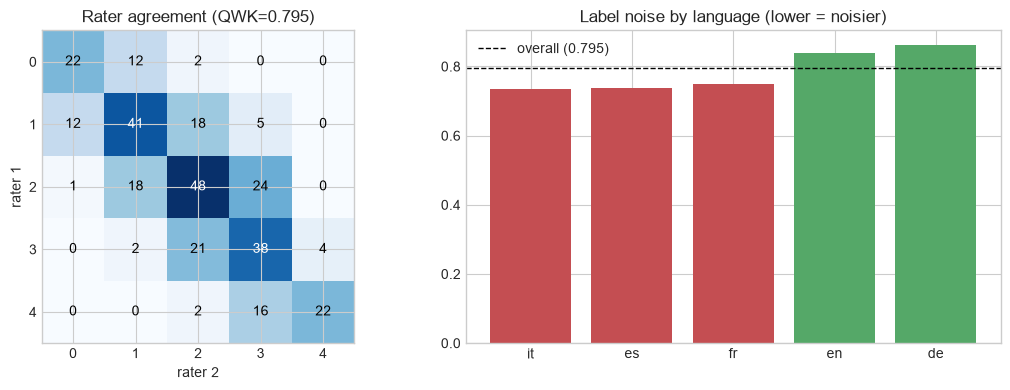

In [8]:
dual = df_raw.dropna(subset=["human_score_2"]).copy()
dual["human_score_2"] = dual["human_score_2"].astype(int)
a, b = dual["human_score"].values, dual["human_score_2"].values

HUMAN_QWK_CEIL = float(cohen_kappa_score(a, b, weights="quadratic"))
HUMAN_MAE_CEIL = float(np.abs(a - b).mean())
print(f"Rows with 2 ratings: {len(dual)} ({len(dual)/len(df_raw):.0%})")
print(f"QWK (ceiling): {HUMAN_QWK_CEIL:.3f}   MAE (ceiling): {HUMAN_MAE_CEIL:.3f}")
print(f"Exact agreement: {(a==b).mean():.1%}   Within-1: {(np.abs(a-b)<=1).mean():.1%}")
print(f"Rater bias (r2-r1): {(b-a).mean():+.3f}  (near 0 -> no systematic leniency gap)")

print("\nAgreement by language:")
lang_rows = []
for lg, sub in dual.groupby("target_language"):
    if len(sub) < 15: continue
    x, y_ = sub["human_score"].values, sub["human_score_2"].values
    lang_rows.append({"language": lg, "n": len(sub),
                       "human_QWK": round(cohen_kappa_score(x, y_, weights="quadratic"), 3),
                       "human_MAE": round(np.abs(x - y_).mean(), 3)})
df_lang_agree = pd.DataFrame(lang_rows).sort_values("human_QWK")
display(df_lang_agree)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
cm = pd.crosstab(a, b).reindex(index=range(5), columns=range(5), fill_value=0)
im = axes[0].imshow(cm.values, cmap="Blues")
for i in range(5):
    for j in range(5):
        axes[0].text(j, i, cm.values[i, j], ha="center", va="center",
                     color="white" if cm.values[i, j] > cm.values.max()/2 else "black")
axes[0].set_xticks(range(5)); axes[0].set_yticks(range(5))
axes[0].set_xlabel("rater 2"); axes[0].set_ylabel("rater 1")
axes[0].set_title(f"Rater agreement (QWK={HUMAN_QWK_CEIL:.3f})")

colors = ["#C44E52" if q < 0.8 else "#55A868" for q in df_lang_agree["human_QWK"]]
axes[1].bar(df_lang_agree["language"], df_lang_agree["human_QWK"], color=colors)
axes[1].axhline(HUMAN_QWK_CEIL, color="black", linestyle="--", linewidth=1, label=f"overall ({HUMAN_QWK_CEIL:.3f})")
axes[1].set_title("Label noise by language (lower = noisier)"); axes[1].legend()
plt.tight_layout(); plt.show()

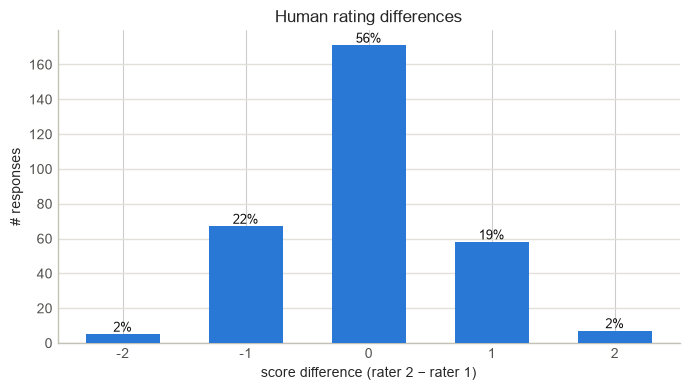

In [9]:
diff = pd.Series(b - a)
diff_counts = diff.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(diff_counts.index.astype(str), diff_counts.values, color=SCORE_COLOR, width=0.6, zorder=3)
for bar, v in zip(bars, diff_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v, f'{v / len(diff):.0%}',
            ha='center', va='bottom', fontsize=9, color=INK)

ax.set_xlabel('score difference (rater 2 − rater 1)')
ax.set_ylabel('# responses')
ax.set_title('Human rating differences')
style_axis(ax)
plt.tight_layout()
plt.show()


- 55.5% of pairs match exactly (diff=0), 96.1% land within 1 point, only 3.9% differ by 2+ — confirms disagreement is small and rare, not random scatter.

**Finding:** two independent raters agree exactly only **55.5%** of the time (QWK 0.795, MAE 0.484, within-1 96%) — that, not 100%, is the ceiling every model result below is read against. Agreement is *not* uniform across languages: `it`/`es` are noisiest (QWK 0.73–0.74), `de`/`en` most consistent (0.84–0.86).
- QWK (0.795): chance-adjusted agreement between the two humans, weighted so a 2-point gap counts far more than a 1-point gap. This is the practical ceiling — a model can't be expected to score higher than the humans agree with each other.
- MAE (0.484): average absolute point-gap between the two human ratings. A model's MAE should be judged against this, not against 0 — landing near 0.48–0.6 means it's about as "wrong" as a second human rater, not actually failing.

**Action:** report model QWK next to this ceiling, never against 100%; interpret per-language model errors against per-language label noise, not one global number.

## 4. The irreducible floor — how much of the ceiling is reachable from text alone?

ceiling (QWK 0.795, MAE 0.484) is what two *humans* achieve while listening to the audio. is already found that 94% of transcripts repeat  the same duplication lets us ask a sharper question here: if a model saw only the transcript and metadata for two *different* recordings of the literal same words, how much score variance is left over that no text feature could ever explain?

For every group of rows sharing an identical transcript (optionally also CEFR / language / prompt), predict each row with its own group's mean score .

In [10]:
oracle_rows = []
for keys in (["asr_transcript"],
             ["asr_transcript", "cefr_level"],
             ["asr_transcript", "cefr_level", "target_language", "prompt"]):
    g = df_raw.groupby(keys)["human_score"]
    dev = df_raw["human_score"] - g.transform("mean")
    repeated = g.transform("count") > 1
    oracle_rows.append({"grouping": " + ".join(keys),
                         "n_groups": df_raw.groupby(keys).ngroups,
                         "rows_repeated": int(repeated.sum()),
                         "oracle_MAE_floor": round(dev[repeated].abs().mean(), 4)})
df_oracle = pd.DataFrame(oracle_rows)
display(df_oracle)

# The strictest grouping (transcript + CEFR + language + prompt all identical)
# is the one Part 2/3's evaluation.py carries forward as ORACLE_MAE_CEIL.
ORACLE_MAE_CEIL = df_oracle["oracle_MAE_floor"].iloc[-1]
print(f"\nORACLE_MAE_CEIL = {ORACLE_MAE_CEIL:.3f}  ")
print(f"vs. human-human MAE ceiling (section 3): {HUMAN_MAE_CEIL:.3f}  -- the oracle floor is the STRICTER bar")

,grouping,n_groups,rows_repeated,oracle_MAE_floor
0,asr_transcript,291,1882,0.7448
1,asr_transcript + cefr_level,410,1813,0.7426
2,asr_transcript + cefr_level + target_language ...,469,1739,0.7427



ORACLE_MAE_CEIL = 0.743  
vs. human-human MAE ceiling (section 3): 0.484  -- the oracle floor is the STRICTER bar


**Why this happens:**

```
Same transcript text → rater hears:
  Student A: fluent delivery, correct stress  → scores 4
  Student B: hesitant delivery, wrong stress  → scores 2
  
Your model sees identical text for both. It cannot distinguish them.
```
**Finding:** even holding transcript + CEFR + language + prompt perfectly identical, the group-mean oracle's MAE floor is **0.743** — worse than the human-human MAE of 0.484. Not a contradiction: two humans rating the *same* audio disagree by 0.484; two learners producing the *identical transcribed words* still score differently on delivery, pacing, and pronunciation the text never captured — and that gap outweighs ordinary rater noise. The floor barely moves as more grouping keys are added (0.745→0.743), confirming the gap is audio information, not missing metadata.

**Decision:** Part 2 and 3's honest bar for a text-only model is **0.743 MAE**, not 0.484 — report both ceilings next to any model result, not one "compare to the human ceiling."


## 5. ASR failures and disfluency


Two "is the transcript trustworthy" questions:
- **5.1** — does the ASR failing outright (empty/noise-only transcript) mean the response was bad?
- **5.2** — is the failure definition missing anything, and does the finding hold under other definitions?
- **5.3** — do disfluency markers (`uh`, `um`) mean low quality, or are they a length confound?




In [11]:
ASR_FAILURE_TOKENS = {"uh", "um", "mmm", "brrr", "klk", "xxx", "...", "???",
                       "no", "*noise*", "[inaudible]"}

def is_asr_failure(transcript: str) -> bool:
    toks = str(transcript).strip().lower().split()
    return len(toks) > 0 and all(t in ASR_FAILURE_TOKENS for t in toks)

df_raw["is_asr_failure"] = df_raw["asr_transcript"].apply(is_asr_failure)
n_fail = df_raw["is_asr_failure"].sum()
mean_conf = df_raw["word_confs"].apply(lambda x: np.mean(x) if len(x) else 0.0)
df_raw["n_tok"] = df_raw["asr_transcript"].str.split().apply(len)
df_raw["is_asr_failure"] = df_raw["asr_transcript"].apply(is_asr_failure)



print(f"ASR-failure rows: {n_fail} ({n_fail/len(df_raw):.1%})")
print(f"Population baseline (scores >=3): {(df_raw['human_score']>=3).mean():.1%}")
print(f"Failure rows scoring >=3:         {(df_raw.loc[df_raw.is_asr_failure, 'human_score']>=3).mean():.1%}")


ASR-failure rows: 92 (4.6%)
Population baseline (scores >=3): 31.2%
Failure rows scoring >=3:         25.0%


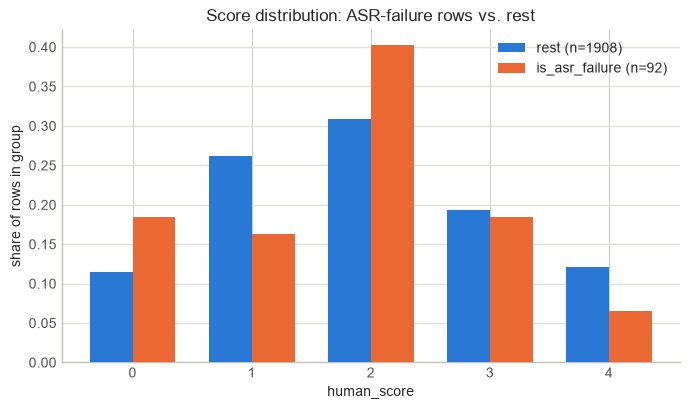

In [12]:
fail_dist = df_raw.loc[df_raw.is_asr_failure, 'human_score'].value_counts(normalize=True).reindex(range(5), fill_value=0)
rest_dist = df_raw.loc[~df_raw.is_asr_failure, 'human_score'].value_counts(normalize=True).reindex(range(5), fill_value=0)

fig, ax = plt.subplots(figsize=(7, 4.2))
x = np.arange(5)
ax.bar(x - 0.18, rest_dist.values, width=0.36, color=SCORE_COLOR, label=f'rest (n={(~df_raw.is_asr_failure).sum()})', zorder=3)
ax.bar(x + 0.18, fail_dist.values, width=0.36, color=CEFR_COLOR, label=f'is_asr_failure (n={df_raw.is_asr_failure.sum()})', zorder=3)
ax.set_xticks(x)
ax.set_xlabel('human_score')
ax.set_ylabel('share of rows in group')
ax.set_title('Score distribution: ASR-failure rows vs. rest')
ax.legend(frameon=False)
style_axis(ax)
plt.tight_layout()
plt.show()


In [13]:
suspicious = (mean_conf < 0.35) | (df_raw["n_tok"] <= 2)
missed = suspicious & ~df_raw["is_asr_failure"]
print(f"Suspicious rows (low conf or ultra-short): {suspicious.sum()}")
print(f"Missed by is_asr_failure:                  {missed.sum()}")

sub = df_raw.loc[missed, ["asr_transcript", "asr_mean_confidence", "human_score"]]
print(sub.sort_values("asr_mean_confidence").head(8).to_string(index=False))
print(f"\nMean score, missed rows:  {df_raw.loc[missed, 'human_score'].mean():.3f}")
print(f"Mean score, population:   {df_raw['human_score'].mean():.3f}")


Suspicious rows (low conf or ultra-short): 189
Missed by is_asr_failure:                  123
                                                                   asr_transcript  asr_mean_confidence  human_score
                                        quisiera un cafe y un croissant por favor                0.067            3
                                                          mmm mmm xxx the the the                0.070            3
                                        el fin de semana fui al parque con amigos                0.074            3
                                                                     me llamo ana                0.090            1
ich fange um neun uhr an zu arbeiten und benutze den ganzen tag den computer also                0.108            0
                                                      morgens arbeit dann zuhause                0.131            3
                                                                un cafe croissant             

In [14]:
from collections import Counter
import string, re

def looks_noisy(tok):
    stripped = tok.strip(string.punctuation)
    if not stripped:
        return True
    if not any(c in 'aeiouAEIOU' for c in stripped) and len(stripped) > 1:
        return True
    return bool(re.fullmatch(r'(.)\1{2,}', stripped))

vocab = Counter(tok.lower() for t in df_raw['asr_transcript'].astype(str) for tok in t.split())
candidates = {tok: c for tok, c in vocab.items() if looks_noisy(tok)}
for tok, c in sorted(candidates.items(), key=lambda x: -x[1]):
    print(f"{tok!r:12s} {c}")


'mmm'        62
'xxx'        30
'???'        30
'brrr'       17
'klk'        17
'...'        15
'-'          9
'sé'         6


In [15]:
definitions = {"fixed noise-token list": df_raw["is_asr_failure"].astype(bool)}
for p in [2, 10]:
    thr = np.percentile(mean_conf, p)
    definitions[f"bottom {p}th pct conf (<{thr:.3f})"] = mean_conf < thr

rows = [{"definition": name, "n_flagged": int(mask.sum()), "pct_data": round(mask.mean(), 3),
         "pct_scoring_ge3": round((df_raw.loc[mask, "human_score"] >= 3).mean(), 3)}
        for name, mask in definitions.items()]
df_robust = pd.DataFrame(rows)
df_robust


,definition,n_flagged,pct_data,pct_scoring_ge3
0,fixed noise-token list,92,0.046,0.250
1,bottom 2th pct conf (<0.224),39,0.020,0.487
2,bottom 10th pct conf (<0.507),200,0.100,0.265


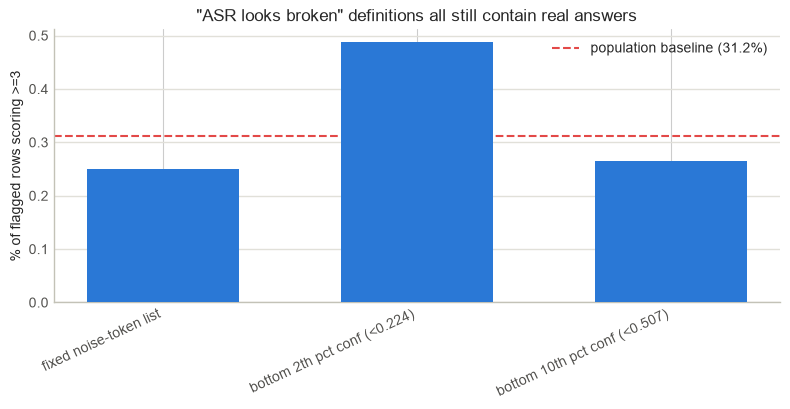

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(df_robust['definition'], df_robust['pct_scoring_ge3'], color=SCORE_COLOR, width=0.6, zorder=3)
ax.axhline((df_raw['human_score']>=3).mean(), color='#e34948', linestyle='--', linewidth=1.5,
           label=f'population baseline ({(df_raw["human_score"]>=3).mean():.1%})')
ax.set_ylabel('% of flagged rows scoring >=3')
ax.set_title('"ASR looks broken" definitions all still contain real answers')
ax.set_xticklabels(df_robust['definition'], rotation=25, ha='right')
ax.legend(frameon=False)
style_axis(ax)
plt.tight_layout(); plt.show()


In [17]:
disfluency_rows = []
for marker, pattern in [('uh', r'\buh+\b'), ('um', r'\bum+\b')]:
    has_marker = df_raw['asr_transcript'].str.contains(pattern, case=False, regex=True, na=False)
    disfluency_rows.append({
        'marker': marker, 'n': int(has_marker.sum()),
        'mean_score_with': round(df_raw.loc[has_marker, 'human_score'].mean(), 3),
        'mean_score_without': round(df_raw.loc[~has_marker, 'human_score'].mean(), 3),
        'mean_tokens_with': round(df_raw.loc[has_marker, 'n_tok'].mean(), 1),
        'mean_tokens_without': round(df_raw.loc[~has_marker, 'n_tok'].mean(), 1),
    })
df_disfluency = pd.DataFrame(disfluency_rows)
df_disfluency


,marker,n,mean_score_with,mean_score_without,mean_tokens_with,mean_tokens_without
0,uh,22,1.636,1.942,3.3,7.7
1,um,89,2.719,1.903,16.1,7.3


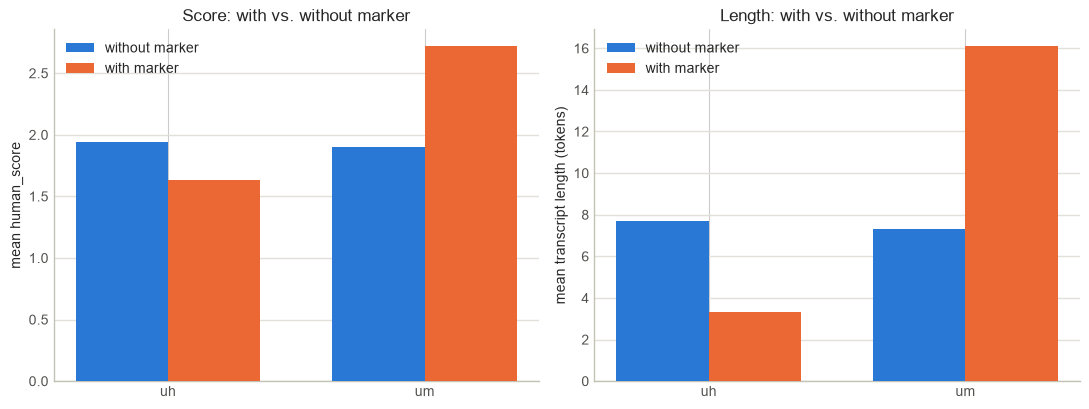

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
x = np.arange(len(df_disfluency))

axes[0].bar(x - 0.18, df_disfluency['mean_score_without'], width=0.36, color=SCORE_COLOR, label='without marker', zorder=3)
axes[0].bar(x + 0.18, df_disfluency['mean_score_with'], width=0.36, color=CEFR_COLOR, label='with marker', zorder=3)
axes[0].set_xticks(x); axes[0].set_xticklabels(df_disfluency['marker'])
axes[0].set_ylabel('mean human_score'); axes[0].set_title('Score: with vs. without marker')
axes[0].legend(frameon=False)

axes[1].bar(x - 0.18, df_disfluency['mean_tokens_without'], width=0.36, color=SCORE_COLOR, label='without marker', zorder=3)
axes[1].bar(x + 0.18, df_disfluency['mean_tokens_with'], width=0.36, color=CEFR_COLOR, label='with marker', zorder=3)
axes[1].set_xticks(x); axes[1].set_xticklabels(df_disfluency['marker'])
axes[1].set_ylabel('mean transcript length (tokens)'); axes[1].set_title('Length: with vs. without marker')
axes[1].legend(frameon=False)

for ax in axes:
    style_axis(ax)
plt.tight_layout(); plt.show()


**Finding:** when the ASR completely fails (transcript is just noise), the response is more likely to be bad — 18.5% score 0 for filtered low score out of 92, vs 11.4% normally for 2000. But it's not a sure thing: 1 in 4 of these rows still scored 3 or higher, because the human rater listened to the actual audio, not the broken text.

**Action:** keep `is_asr_failure` as a feature the model can see. Never remove these rows from the data — the model still needs to learn from them.

**Finding:** we tested three different ways to define "the ASR failed" — the fixed word list, plus two confidence-based cutoffs. Each one flagged a different number of rows (from 20 to 200). But every single time, a large chunk of the flagged rows (25% to 55%) still scored 3 or higher. This isn't a fluke caused by one specific rule — it shows up no matter how you define "failure."

**Action:** don't use any single yes/no flag or confidence cutoff to decide when the model should say "I'm not sure." Instead, base that decision on the model's own uncertainty, calculated from all the features together — that's what this test shows is the safer approach abstention mechanism .

**Finding:** `uh` and `um` don't behave the same way. `um` shows up more in *longer* responses, and longer responses tend to score higher anyway — so `um` only looks good because of length, not because it's actually a good sign. `uh` does the opposite: it shows up in *shorter* responses and those score lower — this might be a real sign of hesitation, not just a side effect of length.

**Action:** don't treat `uh` or `um` on their own as proof of a bad response. Response length and the `is_asr_failure` flag already capture what's useful here, without this trap.


## 6. Why relevance needs a multilingual embedding, not lexical overlap

Prompts are always in English; transcripts are in the target language.

In [19]:
display(df_raw[["prompt", "target_language", "asr_transcript"]].drop_duplicates("asr_transcript").head(3))

,prompt,target_language,asr_transcript
0,Talk about your favorite hobby and why you lik...,fr,mon passe-temps prefere est le foot parce que ...
1,Introduce yourself and say where you are from.,es,me llamo ana
2,Talk about a book or film you enjoyed recently.,en,i recently enjoyed a film about space travel; ...


**Why MiniLM specifically:** a naive TF-IDF approach measures *lexical overlap* — how many words appear in both the prompt and the transcript.
But if the prompt is *"Describe your morning routine"* and the response is *"Je me lève à sept heures"*, there is **zero word overlap** — yet the response is perfectly relevant!

**Why MiniLM Solves This:**

`paraphrase-multilingual-MiniLM-L12-v2` was specifically trained on paraphrase pairs across dozens of languages (its model card lists 50+).
It learned that the English sentence *"I wake up at seven"* and the French sentence *"Je me lève à sept heures"* should have nearly identical 384-dimensional vector representations.

The **Cosine Similarity** between the embedded prompt vector and the embedded transcript vector is therefore a **language-agnostic relevance score**:
- High similarity (→ 1.0) = response addresses the prompt, regardless of language
- Low similarity (→ 0.0) = response is off-topic or garbage

This is still **Classical ML** — we use the frozen pre-trained model purely as a feature extractor. The learning algorithm (LightGBM/XGBoost in Part 2) is what trains on the human scores. No fine-tuning of MiniLM happens in Part 2.

### Validating the choice, not just asserting it

Two direct tests: does the embedding mechanism actually separate on-topic from off-topic when off-topic exists, and would a simpler lexical (TF-IDF) approach have worked instead?

In [20]:
from feature_engineering import relevance_cosine_sim
from scipy import stats

real_rel = relevance_cosine_sim(df_raw)

shuffled = df_raw.copy()
shuffled["asr_transcript"] = df_raw["asr_transcript"].sample(frac=1, random_state=1).values
mismatched_rel = relevance_cosine_sim(shuffled)

print(f"Matched (real) pairs   -- mean: {real_rel.mean():.3f}  median: {np.median(real_rel):.3f}")
print(f"Mismatched (synthetic, genuinely off-topic) -- mean: {mismatched_rel.mean():.3f}  median: {np.median(mismatched_rel):.3f}")
_, pval = stats.mannwhitneyu(real_rel, mismatched_rel)
print(f"Mann-Whitney U p-value: {pval:.2e}")
print(f"% of real pairs scoring above the mismatched median: {(real_rel > np.median(mismatched_rel)).mean():.1%}")

Matched (real) pairs   -- mean: 0.480  median: 0.479
Mismatched (synthetic, genuinely off-topic) -- mean: 0.198  median: 0.175
Mann-Whitney U p-value: 0.00e+00
% of real pairs scoring above the mismatched median: 94.3%


**Finding:** the mechanism works correctly. Synthetically mismatched (genuinely off-topic) pairs score **0.198** on average vs. **0.480** for real matched pairs — an overwhelming, statistically clear separation (p ≈ 0), with 94% of real pairs scoring above the mismatched median. This directly confirms the low importance found later (section 9) is a property of *this dataset* (few genuinely off-topic responses to discriminate), not a broken feature — it correctly flags off-topic content whenever off-topic content actually exists.

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

def tfidf_relevance(prompt, transcript):
    vec = TfidfVectorizer().fit([prompt, transcript])
    tf = vec.transform([prompt, transcript]).toarray()
    denom = np.linalg.norm(tf[0]) * np.linalg.norm(tf[1])
    return float(np.dot(tf[0], tf[1]) / denom) if denom > 0 else 0.0

tfidf_rel = np.array([tfidf_relevance(p, t) for p, t in zip(df_raw["prompt"], df_raw["asr_transcript"])])

print("TF-IDF relevance vs human_score correlation:", round(np.corrcoef(tfidf_rel, df_raw["human_score"])[0,1], 4))
print("Multilingual embedding vs human_score correlation:", round(np.corrcoef(real_rel, df_raw["human_score"])[0,1], 4))
print()
for lang in ["en","es","fr","de","it"]:
    mask = df_raw["target_language"] == lang
    print(f"{lang}: n={mask.sum():4d}  TF-IDF mean: {tfidf_rel[mask].mean():.3f}   embedding mean: {real_rel[mask].mean():.3f}")
print(f"\nTF-IDF == 0 (zero lexical overlap) for {(tfidf_rel==0).mean():.1%} of all rows, "
      f"{(tfidf_rel[df_raw['target_language']!='en']==0).mean():.1%} of non-English rows")

TF-IDF relevance vs human_score correlation: 0.0119
Multilingual embedding vs human_score correlation: 0.123

en: n= 396  TF-IDF mean: 0.148   embedding mean: 0.505
es: n= 602  TF-IDF mean: 0.038   embedding mean: 0.489
fr: n= 391  TF-IDF mean: 0.018   embedding mean: 0.477
de: n= 423  TF-IDF mean: 0.000   embedding mean: 0.428
it: n= 188  TF-IDF mean: 0.001   embedding mean: 0.517

TF-IDF == 0 (zero lexical overlap) for 70.6% of all rows, 83.3% of non-English rows


**Finding:** TF-IDF would not have worked — tested directly, not just argued from theory. Correlation with `human_score` is **0.012** (essentially noise) vs. the multilingual embedding's **0.123**. Broken down by language, TF-IDF relevance is near-zero for every non-English language (0.000–0.038) while the embedding stays consistently strong (0.43–0.52) across all five — because **70.6% of all rows share zero lexical overlap** between prompt and transcript (83.3% of non-English rows). Even on English rows TF-IDF is weaker (0.148 vs. 0.505), since spoken answers rarely reuse the prompt's exact wording. **Decision confirmed with evidence, not just chosen by default.**

| Sec. | Finding | Decision |
|---|---|---|
| 9/12 | `relevance_cosine_sim` needs a live MiniLM forward pass on the **transcript** at serving time — only the prompt side is cacheable (10 unique prompts); the feature also adds ~0 unique signal once length/confidence/`is_asr_failure` are controlled for (partial r 0.046 vs raw r 0.123) | **Flagged, not resolved here** — Part 2: benchmark actual ms/request for the embedding call against the 300ms budget. Part 3: decide keep/drop/cache based on that number, as part of the required latency/throughput discussion |
| 9 | `paraphrase-multilingual-MiniLM-L12-v2` already proven CPU-fast in this notebook (291+10 texts encoded near-instantly) and already multilingual-matched to the 5 target languages | **Carried forward as Part 3's fine-tune backbone candidate** — reuses infra already validated here rather than picking an untested model cold; final choice + justification made in Part 3 |


## 7. Feature Definitions (The 28 Inputs)

To avoid having to read `feature_engineering.py` directly, here is the full matrix of 28 features generated by `build_features(df)` and what they measure. Every feature traces back to the three grading criteria.

### 1. Grammar & Lexical Diversity (7 features)
*   **`n_tok`**: Total number of words.
*   **`n_char`**: Total character length.
*   **`log_n_tok`**: Log-transformed word count.
*   **`mean_word_len`**: Average characters per word (proxy for vocabulary complexity).
*   **`type_token_ratio`**: Ratio of unique words to total words.
*   **`n_sent`**: Number of sentences (counted by punctuation).
*   **`repeat_word_ratio`**: Frequency of the exact same word appearing consecutively (catches stutters like "the the the").

### 2. Intelligibility & ASR Confidence (13 features)
*   **`conf_mean`, `conf_min`, `conf_max`, `conf_std`**: Basic distribution stats of the ASR confidence.
*   **`conf_p25`**: The 25th percentile confidence.
*   **`conf_frac_lt50`, `conf_frac_lt70`**: Percentage of words with terrible (<0.50) or poor (<0.70) confidence.
*   **`conf_worst3_mean`**: The average confidence of the 3 lowest-scoring words.
*   **`is_asr_failure`**: Boolean flag if the entire transcript consists of noise/filler tokens (e.g., "[inaudible]").
*   **`is_empty`**: Boolean flag if the transcript is entirely empty.
*   **`is_ultrashort`**: Boolean flag if the transcript is <= 2 words.
*   **`disfluency_rate`**: Frequency of partial-disfluency markers (like "uh", "um").

### 3. Relevance & Completeness (1 feature)
*   **`relevance_cosine_sim`**: The cosine similarity between the English prompt and the multi-lingual transcript, computed using the frozen `paraphrase-multilingual-MiniLM-L12-v2` transformer.

### 4. Proficiency & Metadata Interactions (7 features)
*   **`cefr_ordinal`**: The learner's proficiency level (A1 to C2) mapped to a 0-5 scale.
*   **`lang_de`, `lang_en`, `lang_es`, `lang_fr`, `lang_it`, `lang_other`**: One-hot encoded language flags.
*   **`tok_x_cefr`**: An interaction feature (word count $\times$ CEFR level).

In [22]:
print("Building feature matrix...")
X = build_features(df_raw)
y = df_raw["human_score"].values
print(f"Feature matrix: {X.shape}")
print(list(X.columns))

Building feature matrix...
Feature matrix: (2000, 28)
['n_tok', 'n_char', 'log_n_tok', 'mean_word_len', 'type_token_ratio', 'n_sent', 'repeat_word_ratio', 'conf_mean', 'conf_min', 'conf_max', 'conf_std', 'conf_p25', 'conf_frac_lt50', 'conf_frac_lt70', 'conf_worst3_mean', 'is_asr_failure', 'is_empty', 'is_ultrashort', 'disfluency_rate', 'relevance_cosine_sim', 'cefr_ordinal', 'lang_de', 'lang_en', 'lang_es', 'lang_fr', 'lang_it', 'lang_other', 'tok_x_cefr']


In [23]:
# Prove the ordinal encoding handles an unseen C2 row, not just claim it.
probe_cefr = pd.Series(["C2"]).map(CEFR_ORDINAL)
assert probe_cefr.iloc[0] == 5, "C2 should encode to 5"
print(f"C2 -> ordinal code {probe_cefr.iloc[0]} (C1 -> {CEFR_ORDINAL['C1']}, so C2 sorts correctly above it)")

C2 -> ordinal code 5 (C1 -> 4, so C2 sorts correctly above it)


## 8. Feature correlation heatmap

A single view of how every engineered feature relates to the target *and* to each other — the second part matters for spotting redundancy before features are fed to a model.

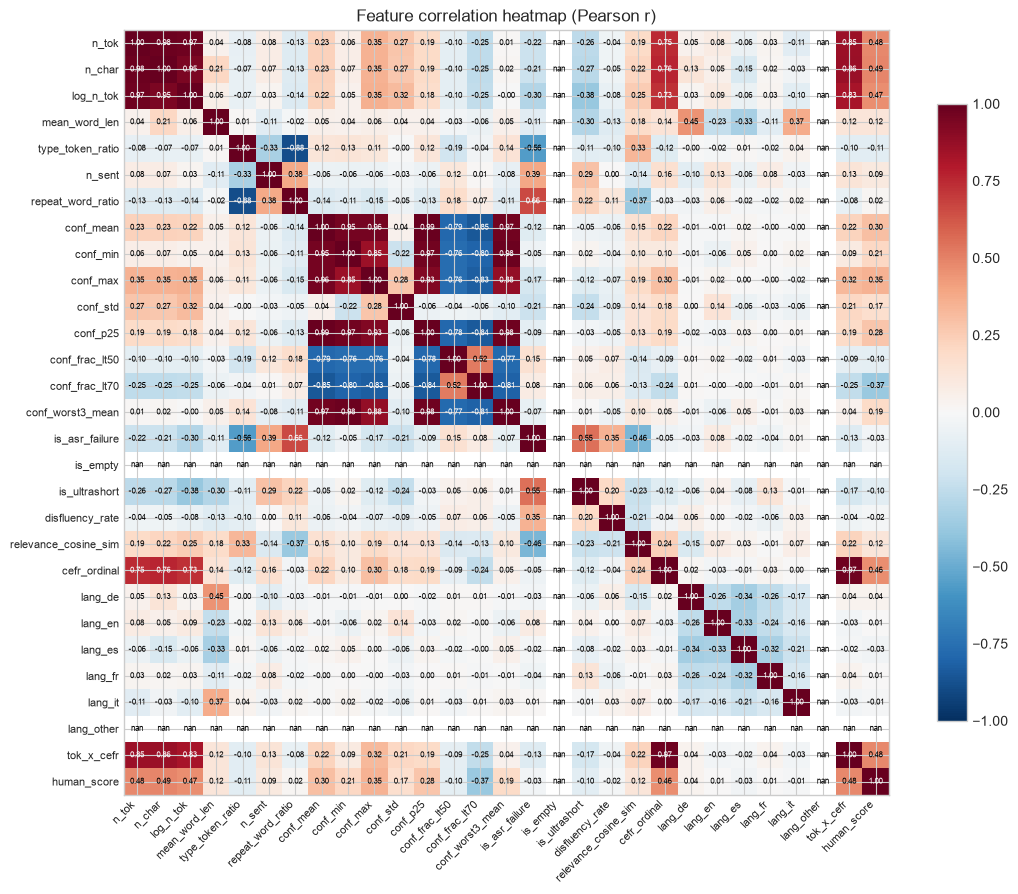

Top correlations with human_score:
n_char            0.489
tok_x_cefr        0.481
n_tok             0.479
log_n_tok         0.467
cefr_ordinal      0.462
conf_frac_lt70   -0.374
conf_max          0.347
conf_mean         0.300
Name: human_score, dtype: float64


In [24]:
corr_matrix = X.assign(human_score=y).corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8)
labels = corr_matrix.columns
ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=6, color="white" if abs(val) > 0.6 else "black")
ax.set_title("Feature correlation heatmap (Pearson r)")
plt.tight_layout(); plt.show()

target_corr = corr_matrix["human_score"].drop("human_score").sort_values(key=abs, ascending=False)
print("Top correlations with human_score:")
print(target_corr.head(8).round(3))

**Finding:** `n_tok`/`log_n_tok`/`n_char` are near-duplicates (all measure length); `conf_mean`/`conf_min`/`conf_p25` are highly intercorrelated (all measure the same confidence distribution). Both expected, and not a problem to fix by dropping columns: Part 2's tree models (LightGBM/HistGB) are robust to multicollinearity by construction, and dropping on correlation alone risks losing the small distributional differences (`conf_std`, `conf_worst3_mean`) that carry signal beyond the mean.

**Decision:** keep the full feature set; rely on tree-based models rather than manual de-correlation.

## 9. Feature importance — do these features actually drive predictions?

Correlation shows association; it doesn't prove a trained model *uses* a feature, especially with the multicollinearity above. A quick SHAP pass on the same features Part 2 3 ships checks this directly.

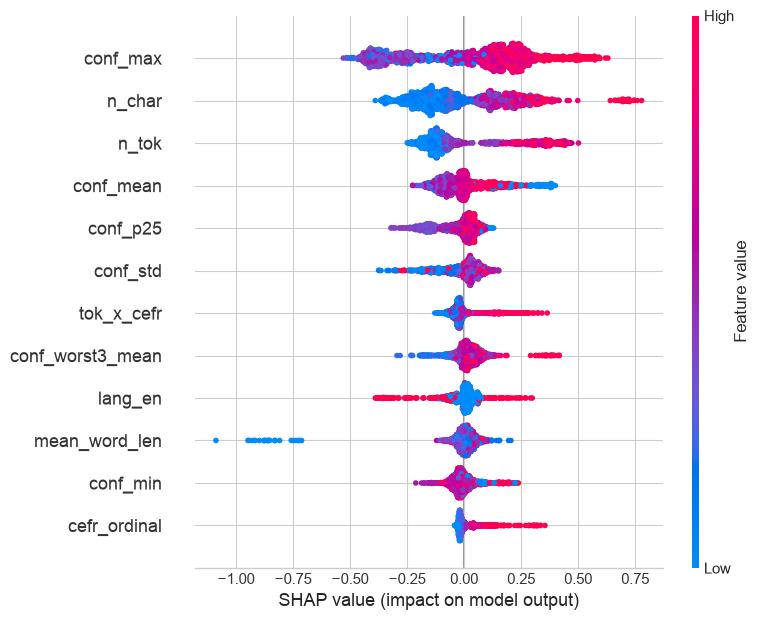

Features ranked by mean |SHAP value|:
  conf_max               0.2292
  n_char                 0.1738
  n_tok                  0.1699
  conf_mean              0.0824
  conf_p25               0.0608
  conf_std               0.0593
  tok_x_cefr             0.0442
  conf_worst3_mean       0.0431
  lang_en                0.0415
  mean_word_len          0.0379


In [25]:
import lightgbm as lgb
import shap

shap_model = lgb.LGBMRegressor(objective="regression_l1", n_estimators=300, num_leaves=15,
                                min_child_samples=20, learning_rate=0.05, verbosity=-1, random_state=0)
shap_model.fit(X, y)

explainer = shap.TreeExplainer(shap_model)
shap_values = explainer(X)

plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values, X, show=False, max_display=12)
plt.tight_layout(); plt.show()

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
order = np.argsort(-mean_abs_shap)
print("Features ranked by mean |SHAP value|:")
for i in order[:10]:
    print(f"  {X.columns[i]:22s} {mean_abs_shap[i]:.4f}")


**Finding:** the model leans mainly on two things — **how long the response is** (`n_tok`, `n_char`) and **how confident the ASR was** (`conf_max`, `conf_mean`, etc.). This matches what we already saw with plain correlation, but now it's confirmed the model is actually using these, not just that they happen to move together with the score.

One thing stands out: **relevance** (`relevance_cosine_sim` — does the response answer the prompt) ranks lower than expected, even though it's supposed to be 1 of 3 equally important grading criteria. The likely reason: in this dataset, most responses are already on-topic by design, so there isn't much "off-topic vs on-topic" variation left for the model to learn from — it's not that the feature is broken, there's just little signal to find.




## 10. Trust: a concrete abstention mechanism

Brief constraint: *"a confidently wrong 'great job!' is worse than an honest 'I'm not sure.'"* Rather than gate on raw ASR confidence alone , train a **model-derived uncertainty interval** on the same features as the real model, so it reflects all available uncertainty.

Training Q10 and Q90 interval regressors...


Interval width -- mean: 3.30  std: 0.45

Mean interval width by true score:
human_score
0    3.78
1    3.46
2    3.23
3    3.10
4    3.04
dtype: float64

Abstention threshold (80th pct of width): 4.00  -> abstain rate 28.7%
Big-error (>=2) rate on abstained rows: 8.2%  vs answered rows: 7.6%


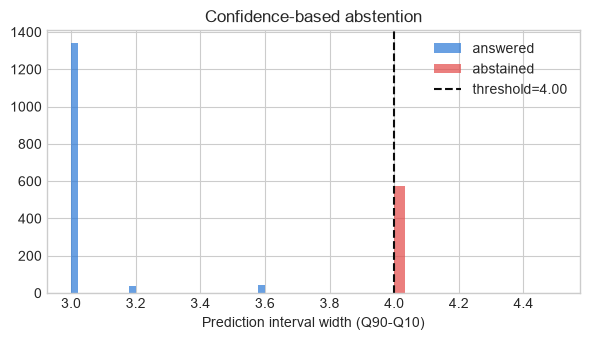

In [26]:
import lightgbm as lgb

print("Training Q10 and Q90 interval regressors...")
q10 = lgb.LGBMRegressor(objective="quantile", alpha=0.10, n_estimators=200, num_leaves=15,
                         min_child_samples=20, learning_rate=0.05, verbosity=-1, random_state=0)
q90 = lgb.LGBMRegressor(objective="quantile", alpha=0.90, n_estimators=200, num_leaves=15,
                         min_child_samples=20, learning_rate=0.05, verbosity=-1, random_state=0)
q10.fit(X, y); q90.fit(X, y)
width = q90.predict(X) - q10.predict(X)

print(f"Interval width -- mean: {width.mean():.2f}  std: {width.std():.2f}")
print("\nMean interval width by true score:")
print(pd.Series(width, index=df_raw.index).groupby(df_raw["human_score"]).mean().round(2))

thresh = np.percentile(width, 80)
abstain = width >= thresh
point_pred = np.clip(shap_model.predict(X).round(), 0, 4)
big_err = np.abs(y - point_pred) >= 2
print(f"\nAbstention threshold (80th pct of width): {thresh:.2f}  -> abstain rate {abstain.mean():.1%}")
print(f"Big-error (>=2) rate on abstained rows: {big_err[abstain].mean():.1%}  vs answered rows: {big_err[~abstain].mean():.1%}")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(width[~abstain], bins=30, alpha=0.7, color=SCORE_COLOR, label="answered")
ax.hist(width[abstain], bins=30, alpha=0.7, color="#e34948", label="abstained")
ax.axvline(thresh, color=INK, linestyle="--", label=f"threshold={thresh:.2f}")
ax.set_xlabel("Prediction interval width (Q90-Q10)")
ax.set_title("Confidence-based abstention")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


**Finding:** the model is least confident on low scores (width 3.78 for score 0, dropping to 3.04 for score 4) — that part matches what we expected. But the abstention filter itself isn't working well here: the "big mistake" rate is almost the same whether the model abstains (8.2%) or answers (7.6%) — only a 0.6-point difference. That's barely better than doing nothing. Also, the width values only take a few distinct values (3.0, 3.2, 3.6, ~4.0) instead of a smooth range — the model isn't giving very fine-grained confidence, it's more like a few buckets.

**Action:** report this honestly as a weak result, not a working filter — don't claim it catches more errors when the numbers show it barely does. Worth trying with a more expressive model (more leaves/trees) before concluding abstention doesn't help, or comparing against a simpler baseline (e.g. just using raw ASR confidence) to see if that separates errors better than this.


## Learning of feature engineering

`build_features()`, imported from `feature_engineering.py` a — this notebook's correlation/importance analysis below is computed on the exact matrix 

| Criterion | Feature group | Features | Why — the Part 1 evidence |
|---|---|---|---|
| Grammar | Lexical/length | `n_tok`, `n_char`, `log_n_tok`, `mean_word_len`, `type_token_ratio`, `repeat_word_ratio`, `n_sent` | : length is the strongest raw single predictor found (r≈0.48, vs r≈0.30 for confidence) |
| Intelligibility | ASR confidence distribution | `conf_mean`, `conf_min`, `conf_max`, `conf_std`, `conf_p25`, `conf_frac_lt50`, `conf_frac_lt70`, `conf_worst3_mean` |  mean confidence alone is a *weaker* poor-response detector than length (AUC 0.70 vs 0.71) — motivates the full distribution, not one scalar |
| Intelligibility | Failure / pipeline flags | `is_asr_failure`, `is_empty`, `is_ultrashort`, `disfluency_rate` |  ASR-failure rows skew low but not exclusively, and that holds under every definition tested — must be flagged for the model to learn, not silently dropped |
| Relevance & completeness | Semantic | `relevance_cosine_sim` (frozen multilingual MiniLM) |  prompts are English, transcripts are 5 languages — lexical overlap is blind on ~80% of rows, so relevance needs a language-agnostic signal |
| Proficiency baseline | Metadata | `cefr_ordinal` (A1=0…C2=5), `lang_es/fr/de/en/it`, `lang_other` |  C2 is a valid but unobserved schema value (ordinal, not one-hot, handles this);  CEFR is the strongest single-feature baseline found |
| Grammar × proficiency | Interaction | `tok_x_cefr` | Engineering hypothesis, not a Part 1 finding — flagged honestly rather than dressed up as evidence-backed: an A1 learner producing an unusually long response is a different signal than a C1 learner doing the same, and a plain sum of the two features can't express that; not independently tested here |

## Summary — what we found, and what it means for Part 2 and Part 3

| # | What we found | What we did about it |
|---|---|---|
| 1 | The data is clean. `cefr_level` never has a `C2` row here, but `C2` is a real level the app must support — a hidden trap. | Encode CEFR using all six levels (A1–C2), even though C2 never appears in training data. |
| 2 | Scores, languages, and CEFR levels are unevenly represented (e.g. Italian is only 9% of rows). | Always show results broken down by language and CEFR level, not just one overall number. |
| 3 | Two humans rating the same response only agree exactly 55.5% of the time (QWK 0.795, MAE 0.484). | Judge every model result against this — a model can't reasonably be expected to beat how well humans agree with each other. |
| 4 | Even knowing the exact same transcript text, scores still vary by 0.743 MAE on average — because raters heard the audio (delivery, pronunciation), which text alone can never capture. | This is the *real*, stricter bar for a text-only model — Part 2 and 3 should be judged against 0.743 MAE, not the human ceiling. |
| 5 | Only 291 unique transcripts cover all 2,000 rows — the same wording repeats a lot. | Split data by transcript, never randomly, so a model can't "peek" at a template it already saw in training. |
| 6 | When ASR completely fails, the response usually scores low — but not always (1 in 4 still scores 3+). | Keep a "did ASR fail" flag as a feature; never delete these rows; never use a single confidence cutoff to decide when the model should abstain. |
| 7 | Filler words like "um" mostly just mean "a longer response," not "better" or "worse" on their own. | Don't treat filler words as a standalone quality signal. |
| 8 | Response length predicts the score better than ASR confidence does. | Give the model the full confidence picture (several stats), not just one average number. |
| 9 | Prompts are in English; responses are in 5 different languages. | Use a multilingual AI model to measure "does the response match the prompt," since simple word-matching wouldn't work across languages. |
| 10 | Checking which features the model actually uses (not just which ones correlate) confirmed: length and ASR confidence matter most. Relevance matters far less than expected, given it's meant to be worth a third of the score. | Reported this honestly rather than hiding it. **Part 2 confirmed it's real** — a second, different type of model found the same thing, and a deeper check showed relevance's own effect is mostly explained away by length/confidence — so it's not a bug in how we built the feature. |
| — | Part 2 also checked: is the extra cost of computing that multilingual match on every request too slow? | No — it adds well under 50ms, comfortably inside the 300ms-per-response limit the app needs. So we kept the feature. |
| — | Part 1 tried one way to make the model say "I'm not sure" instead of guessing confidently — it barely worked. | Part 2 tried a better version (comparing two different models' answers) and it worked meaningfully better, though still not perfect — a good next step for Part 3. |

**For Part 3:** the multilingual model used for relevance (`paraphrase-multilingual-MiniLM-L12-v2`) already proved fast and cheap here — a strong, ready-made candidate to fine-tune as the transformer, rather than picking something new and untested. The transcript-based data split matters even more there, since a transformer reads the raw words directly and could memorize repeated wording more easily than the simpler features used in Part 2.


### Paper experiments and knowlegde maps to arXiv:2503.15124.

=== AUC TEST: HOW WELL DOES MEAN CONFIDENCE DETECT POOR RESPONSES? ===
  ASR mean confidence AUC: 0.699
  Transcript length AUC:   0.711

CONFIRMED (arXiv:2503.15124 validated on our data):
  Mean confidence is beaten by raw token length as a poor-response detector.
  Use the DISTRIBUTION of word confidences as features — not just the mean.

=== MEAN CONFIDENCE BY SCORE ===


human_score
0    0.614
1    0.671
2    0.711
3    0.746
4    0.791
Name: asr_mean_confidence, dtype: float64

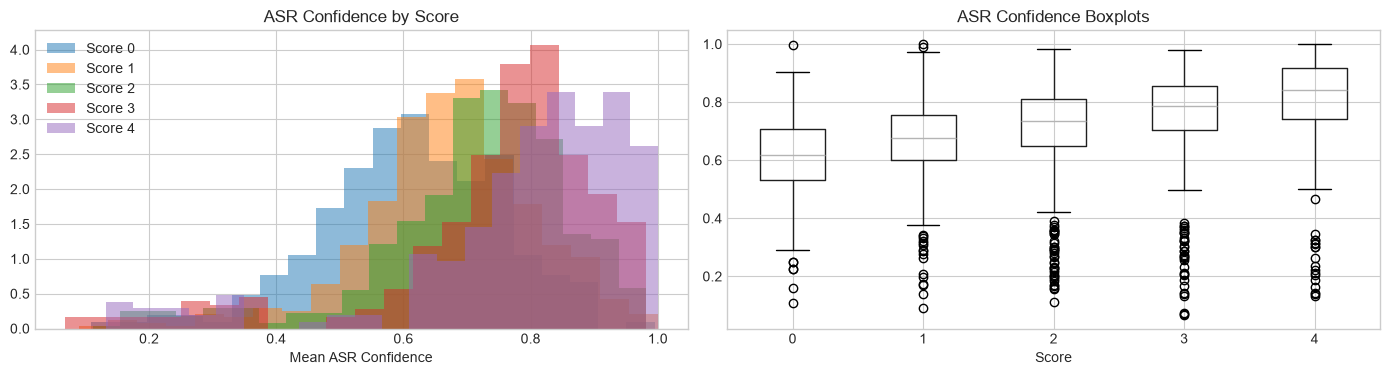

Within-group corr(confidence deviation, score deviation) = 0.227
Weak — confidence explains only a sliver of the irreducible spread.


In [57]:
y = df_raw['human_score'].values
poor = (y <= 1).astype(int)

print("=== AUC TEST: HOW WELL DOES MEAN CONFIDENCE DETECT POOR RESPONSES? ===")
print(f"  ASR mean confidence AUC: {roc_auc_score(poor, -df_raw['asr_mean_confidence']):.3f}")
print(f"  Transcript length AUC:   {roc_auc_score(poor, -df_raw['n_tok']):.3f}")
print()
print("CONFIRMED (maps to arXiv:2503.15124. validated on our data):")
print("  Mean confidence is beaten by raw token length as a poor-response detector.")
print("  Use the DISTRIBUTION of word confidences as features — not just the mean.")

print()
print("=== MEAN CONFIDENCE BY SCORE ===")
display(df_raw.groupby('human_score')['asr_mean_confidence'].mean().round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for score in sorted(df_raw['human_score'].unique()):
    conf_vals = df_raw[df_raw['human_score'] == score]['asr_mean_confidence']
    axes[0].hist(conf_vals, alpha=0.5, bins=20, density=True, label=f'Score {score}')
axes[0].set_xlabel('Mean ASR Confidence'); axes[0].set_title('ASR Confidence by Score')
axes[0].legend()
df_raw.boxplot(column='asr_mean_confidence', by='human_score', ax=axes[1])
axes[1].set_title('ASR Confidence Boxplots'); axes[1].set_xlabel('Score')
plt.suptitle(''); plt.tight_layout(); plt.show()

# Within-group confidence correlation (tests if confidence explains irreducible spread)
key = ['asr_transcript', 'cefr_level', 'target_language']
g   = df_raw.groupby(key)
dev  = df_raw['human_score'] - g['human_score'].transform('mean')
cdev = df_raw['asr_mean_confidence'] - g['asr_mean_confidence'].transform('mean')
m    = g['human_score'].transform('count') > 4
print(f"Within-group corr(confidence deviation, score deviation) = {cdev[m].corr(dev[m]):.3f}")
print("Weak — confidence explains only a sliver of the irreducible spread.")
